In [1]:
  # This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Data Loading 

In [2]:
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


# Inspection of Data

In [3]:
df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


Conclusion : Need of Encoding 

In [5]:
df.shape

(2000, 8)

In [6]:
df.isna().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
(df['answer'].value_counts()/df.shape[0])*100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: count, dtype: float64

<Axes: xlabel='answer', ylabel='count'>

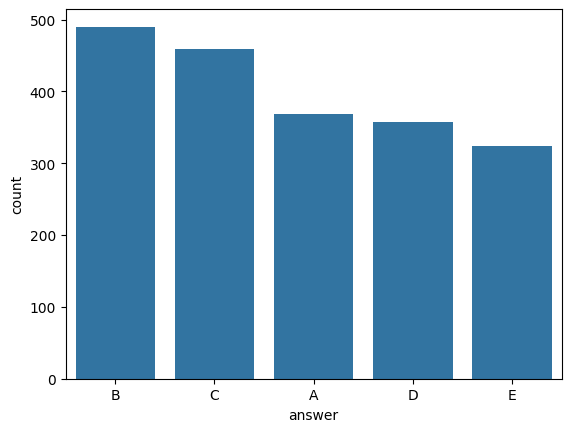

In [9]:
import seaborn as sns

sns.countplot(x=df['answer'], data=df, order=df['answer'].value_counts().index)

In [10]:
x=df['answer'].value_counts().max() +  df['answer'].value_counts().min()

print("Sum of Most frequent and least frequent options in answer column =",x)

Sum of Most frequent and least frequent options in answer column = 814


# Data cleaning 
Creating Vocab 
* removing punctuation
* split by space 

In [11]:
import string
has_punctuation = df["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[ True]


In [12]:
import string
def clean_text(text):
    text=text.lower()
    text=text.strip()
    translator=str.maketrans('','',string.punctuation) #nothing,nothing,delete punctuation 
    text=text.translate(translator)
    return text
    

In [13]:
for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)

In [14]:
#verifying 
has_punctuation = df["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[False]


Train -Test Split 

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="answer")
y = df['answer']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Map@3 Metric 


In [16]:
def map3(y_true, top3_preds):
    score = 0

    for actual, pred in zip(y_true, top3_preds):
        if actual == pred[0]:
            score += 1.0

        elif actual == pred[1]:
            score += 0.5

        elif actual == pred[2]:
            score += 1/3

    return score / len(y_true)

# Base line model 

In [17]:
counts = df['answer'].value_counts()

top3 = counts.index[:3].tolist()

print(top3)

['B', 'C', 'A']


In [18]:
y_pred = [top3] * len(X_train)

In [19]:
print("Majority class baseline : ",round(map3(y_train,y_pred),3)) #train dataset and its a dummy classifier

Majority class baseline :  0.421


# Tfidf + cosine similarity 

In [20]:
train_text=pd.concat([
    X_train["prompt"],
    X_train["A"],
    X_train["B"],
    X_train["C"],
    X_train["D"],
    X_train["E"]
])

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer= TfidfVectorizer( ngram_range=(1,3), lowercase=False,
    max_features=80000,
    min_df=2,stop_words="english")
vectorizer.fit(train_text)


TfidfVectorizer(lowercase=False, max_features=80000, min_df=2,
                ngram_range=(1, 3), stop_words='english')

In [22]:
def transform_columns(df,vectorizer):
    return (
        vectorizer.transform(df["prompt"]),
        vectorizer.transform(df["A"]),
        vectorizer.transform(df["B"]),
        vectorizer.transform(df["C"]),
        vectorizer.transform(df["D"]),
        vectorizer.transform(df["E"])
    )

In [23]:
prompt_vec, A_vec, B_vec, C_vec, D_vec, E_vec = transform_columns(X_train, vectorizer)

prompt_val, A_val, B_val, C_val, D_val, E_val = transform_columns(X_val, vectorizer)


In [24]:
from sklearn.metrics.pairwise import cosine_similarity
print("shape of comparing prompt with A_vector",cosine_similarity(prompt_vec, A_vec).diagonal().shape)
scores = {
    'A': cosine_similarity(prompt_vec, A_vec).diagonal(),
    'B': cosine_similarity(prompt_vec, B_vec).diagonal(),
    'C': cosine_similarity(prompt_vec, C_vec).diagonal(),
    'D': cosine_similarity(prompt_vec, D_vec).diagonal(),
    'E': cosine_similarity(prompt_vec, E_vec).diagonal()
}
scores_val = {
    'A': cosine_similarity(prompt_val, A_val).diagonal(),
    'B': cosine_similarity(prompt_val, B_val).diagonal(),
    'C': cosine_similarity(prompt_val, C_val).diagonal(),
    'D': cosine_similarity(prompt_val, D_val).diagonal(),
    'E': cosine_similarity(prompt_val, E_val).diagonal()
}


shape of comparing prompt with A_vector (1600,)


In [25]:
def top3preds(scores_dict):
    preds = []

    for i in range(len(scores_dict["A"])):

        row_scores = {
            "A": scores_dict["A"][i],
            "B": scores_dict["B"][i],
            "C": scores_dict["C"][i],
            "D": scores_dict["D"][i],
            "E": scores_dict["E"][i]
        }

        top3 = []

        for k in range(3):

            best_opt = None
            best_score = -1

            for option, score in row_scores.items():

                if score > best_score:
                    best_score = score
                    best_opt = option

            top3.append(best_opt)
            row_scores.pop(best_opt)

        preds.append(top3)

    return preds

top3_list_val=top3preds(scores_val)
top3_list_train=top3preds(scores)

In [26]:
map3(y_train,top3_list_train)

0.3379166666666659

In [27]:
map3(y_val,top3_list_val)

0.3054166666666664

# **Conclusion**  
Tfidf + cosine similarity gives 0.28 map@3 score on unknown data 

# LR model 
 

In [28]:
from sklearn.linear_model import LogisticRegression

Converting prompt to prompt+option format with label and when prompt and  true option is paired then gives label as 1 . thus converted multiclass labels to binary class labels 

In [29]:
def expand_to_binary(X, y):
    rows = []
    for (idx, row), label in zip(X.iterrows(), y):
        for opt in ['A', 'B', 'C', 'D', 'E']:
            rows.append({
                'text': row['prompt'] + ' ' + row[opt],
                'label': 1 if label == opt else 0
            })
    return pd.DataFrame(rows)


In [30]:

train_binary = expand_to_binary(X_train, y_train)
print("Train binary shape:", train_binary.shape)
print(train_binary['label'].value_counts())


Train binary shape: (8000, 2)
label
0    6400
1    1600
Name: count, dtype: int64


In [31]:

X_train_vec = vectorizer.fit_transform(train_binary['text'])  # fit ONLY on train

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, train_binary['label'])


LogisticRegression(max_iter=1000)

In [32]:

#  INFERENCE 
def predict_top3(row):

    options = ["A", "B", "C", "D", "E"]

    texts = []

    for option in options:
        texts.append(row["prompt"] + " " + row[option])

    probs = lr.predict_proba(vectorizer.transform(texts))[:, 1]

    scores = []

    for i in range(5):
        scores.append((options[i], probs[i]))

    scores.sort(key=lambda x: x[1], reverse=True)

    return [scores[0][0], scores[1][0], scores[2][0]]


In [33]:

top3_val = [predict_top3(row) for _, row in X_val.iterrows()]
print("Validation MAP@3:", round(map3(y_val, top3_val), 4))


Validation MAP@3: 0.9846


## Conclusion of lr model

The **0.9846** validation score reflects lexical memorization of training patterns. The **0.75** leaderboard score reflects real-world generalization.

## Dl model PreTrained 

Disclaimer : I used independent run of section strategy so that i dont have to run the cells from start thus i have redundant code base.


In [34]:
import wandb

from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

wandb_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_key)
wandb.init(
    project="23f2005464-t22026",
    name="bert-baseline_with_groupsplit"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f2005464 (23f2005464-iit-madras-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run a8nkufzd
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260730_182644-a8nkufzd
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run bert-baseline_with_groupsplit
wandb: ⭐️ View project at https://wandb.ai/23f2005464-iit-madras-/23f2005464-t22026
wandb: 🚀 View run at https://wandb.ai/23f2005464-iit-madras-/23f2005464-t22026/runs/a8nkufzd


In [35]:
from sklearn.model_selection import train_test_split
import pandas as pd

I suspect that may be train data has some duplicates as used earlier with id column i got no duplicates and after that got a duplicates ,post id removable situation . Because i am preety under confident about validation map3 score because it jumps towards 92 to 99 approx.

In [36]:

df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)


duplicates = df.duplicated(subset=df.columns.drop("id")).sum()
print("Duplicates without id column ",duplicates)

df = df.drop_duplicates(subset=df.columns.drop("id")).reset_index(drop=True)


Duplicates without id column  183


In [37]:
import re

def clean_text(text):
    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text
columns = ["prompt", "A", "B", "C", "D", "E"]

for col in columns:
    X_train[col] = X_train[col].apply(clean_text)
    X_val[col] = X_val[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)
    

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer().fit_transform(df["prompt"])

sim = cosine_similarity(tfidf)
import numpy as np
print(len(df))
np.fill_diagonal(sim, 0)
threshold = 0.90

pairs = np.argwhere(sim > threshold)

print("Highly similar pairs:", len(pairs))
for i, j in pairs[:20]:
    print("="*50)
    print(df.loc[i, "prompt"])
    print()
    print(df.loc[j, "prompt"])
    print("Similarity:", sim[i, j])

1817
Highly similar pairs: 5948
pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options

which of the following is correct what is martin heideggers view on the relationship between time and human existence among the listed options
Similarity: 0.9209534366946229
pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options

what is martin heideggers view on the relationship between time and human existence
Similarity: 0.9060951056453264
what is acceleratorbased lightion fusion

determine the correct option what is acceleratorbased lightion fusion
Similarity: 0.9385765936351547
what is acceleratorbased lightion fusion

choose the correct answer what is acceleratorbased lightion fusion carefully
Similarity: 0.91144169137457
what is acceleratorbased lightion fusion

choose the correct answer what is acceleratorbased lightion fusion

New Technique use for reducing overfitting chances. Post exectuion situation is not favourable , it is like reduced map score at leader board.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import GroupShuffleSplit

from scipy.cluster.hierarchy import dendrogram

import matplotlib.pyplot as plt
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=1
)

X = vectorizer.fit_transform(df["prompt"])
similarity = cosine_similarity(X)
distance = 1 - similarity

clusterer = AgglomerativeClustering(
    metric="precomputed",
    linkage="average",
    n_clusters=None,
    distance_threshold=0.30
)

df["template_id"] = clusterer.fit_predict(distance)
cluster_sizes = df["template_id"].value_counts()
print("Number of clusters:", df["template_id"].nunique())

Number of clusters: 336


In [40]:
from sklearn.model_selection import StratifiedGroupKFold

gss = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        df,
        y=df["answer"],              # optional
        groups=df["template_id"]
    )
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print(f"Train size      : {len(train_df)}")
print(f"Validation size : {len(val_df)}")

Train size      : 1472
Validation size : 345


In [41]:
X_train = train_df.drop(columns=["answer", "template_id"])
X_val = val_df.drop(columns=["answer", "template_id"])
y_train = train_df["answer"]
y_val = val_df["answer"]


In [42]:
X_train.columns
print(f"Train size: {len(X_train)} | Val size: {len(X_val)}")

Train size: 1472 | Val size: 345


# Bert Model Pipeline


In [43]:
import transformers
import torch
from transformers import AutoModel, BertTokenizerFast

OPTIONS = ["A", "B", "C", "D", "E"]
LABEL2ID={opt: i for i, opt in enumerate(OPTIONS)}
device = torch.device("cuda")
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [44]:
print("Model Max Length",tokenizer.model_max_length)
print("vocab size",tokenizer.vocab_size)

Model Max Length 512
vocab size 30522


In [45]:
def pairs(df, y=None):
    rows = []

    for i, (_, row) in enumerate(df.iterrows()):
        prompt = row["prompt"]

        for option in ["A", "B", "C", "D", "E"]:

            pair = {
                "prompt": prompt,
                "option": row[option],
                "option_name": option
            }

            if y is not None:
                pair["label"] = int(y.iloc[i] == option)

            rows.append(pair)

    return pd.DataFrame(rows)

In [46]:
train_pairs=pairs(X_train,y_train)
val_pairs=pairs(X_val,y_val)
test_pairs=pairs(test_df)

test_pairs.head()

,prompt,option,option_name
0,pick the best possible answer what is the rela...,for every eigenstate of one hamiltonian its pa...,A
1,pick the best possible answer what is the rela...,for every eigenstate of one hamiltonian its pa...,B
2,pick the best possible answer what is the rela...,for every eigenstate of one hamiltonian its pa...,C
3,pick the best possible answer what is the rela...,for every eigenstate of one hamiltonian its pa...,D
4,pick the best possible answer what is the rela...,for every eigenstate of one hamiltonian its pa...,E


Deciding length of token max_length allowed boundary

In [47]:

import numpy as np

lengths = []

for prompt, option in zip(train_pairs["prompt"], train_pairs["option"]):
    tokens = tokenizer.encode(prompt, option, add_special_tokens=True)
    lengths.append(len(tokens))


print("Maximum :", max(lengths))
print("Average :", np.mean(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("99th percentile:", np.percentile(lengths, 99))

Maximum : 176
Average : 55.10244565217391
95th percentile: 94.0
99th percentile: 120.0


options of max length 64, 128, 256, or 512  AND we are using 128 bcoz our 95 percentage of data is 105 or less.


## Tokenization 

In [48]:
x_train_encodings= tokenizer(
     train_pairs["prompt"].tolist(),
     train_pairs["option"].tolist(),
     padding="max_length",
     truncation=True,
     max_length=128,
     return_tensors="pt"
          )
x_val_encodings=tokenizer(
   val_pairs["prompt"].tolist(),
    val_pairs["option"].tolist(),
    padding="max_length",
    truncation=True,
     max_length=128,
      return_tensors="pt"
)
test_encodings=tokenizer(
   test_pairs["prompt"].tolist(),
    test_pairs["option"].tolist(),
    padding="max_length",
    truncation=True,
     max_length=128,
      return_tensors="pt"
)
train_labels = torch.tensor(train_pairs["label"].tolist(), dtype=torch.long)
val_labels = torch.tensor(val_pairs["label"].tolist(), dtype=torch.long)

In [49]:
from torch.utils.data import Dataset

class MCQDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

In [50]:
from torch.utils.data import Dataset

class BertTestDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {
            key: value[idx]
            for key, value in self.encodings.items()
        }

In [51]:
train_dataset = MCQDataset(
    x_train_encodings,
    train_labels
)

val_dataset = MCQDataset(
    x_val_encodings,
    val_labels
)


print(len(train_df), len(val_df))
print(len(set(train_df["template_id"]) &
          set(val_df["template_id"])))

1472 345
0


In [52]:
from sklearn.metrics import accuracy_score, f1_score
def map3_score(logits, labels):
    top3_preds = np.argsort(logits, axis=1)[:, -3:][:, ::-1]

    scores = []

    for preds, label in zip(top3_preds, labels):
        if label == preds[0]:
            scores.append(1.0)
        elif label == preds[1]:
            scores.append(0.5)
        elif label == preds[2]:
            scores.append(1/3)
        else:
            scores.append(0.0)

    return np.mean(scores)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {
        "map3": map3_score(logits, labels),
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

In [53]:
from transformers import TrainingArguments, Trainer
from transformers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./mcq_model",

    # Training settings
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",# Saving model
    save_total_limit=2,

    # Learning rate
    learning_rate=1e-5,
    weight_decay=0.03,
    # Logging
    logging_steps=50,

    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model="map3",
    greater_is_better=True,
    report_to="wandb",
   
)

In [54]:
print(type(train_dataset))

<class '__main__.MCQDataset'>


In [55]:
from transformers import BertForSequenceClassification

bertmodel=BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
bertmodel.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cuda


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [56]:
trainer = Trainer(
    model=bertmodel,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,
     callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Map3,Accuracy,F1
1,0.980670,0.997233,0.900000,0.800000,0.711111
2,0.827857,1.004707,0.900870,0.801739,0.723429
3,0.604762,1.054169,0.889565,0.779130,0.768256
4,0.442642,1.133474,0.897971,0.795942,0.784813


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=920, training_loss=0.7667123234790304, metrics={'train_runtime': 449.9562, 'train_samples_per_second': 81.786, 'train_steps_per_second': 2.556, 'total_flos': 1936497367449600.0, 'train_loss': 0.7667123234790304, 'epoch': 4.0})

Creating Submission function 

In [57]:
import torch
import pandas as pd
from torch.utils.data import DataLoader

def create_submission(
    model,
    test_encodings,
    test_df,
    device,
    batch_size=8,
    filename="submission.csv"
):
    # Dataset
    test_dataset = BertTestDataset(test_encodings)

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model.eval()

    logits_list = []

    with torch.no_grad():

        for batch in test_loader:

            batch = {
                k: v.to(device)
                for k, v in batch.items()
            }

            outputs = model(**batch)

            logits_list.append(outputs.logits.cpu())

    logits = torch.cat(logits_list).numpy()
    if logits.ndim == 2:
        scores = logits[:, 1]
    else:
        scores = logits

    scores = scores.reshape(-1, 5)
    # Top-3 predictions
    options = ["A", "B", "C", "D", "E"]

    top3 = scores.argsort(axis=1)[:, -3:][:, ::-1]

    predictions = [
        " ".join(options[i] for i in row)
        for row in top3
    ]

    submission = pd.DataFrame({
        "id": test_df["id"],
        "prediction": predictions
    })

    submission.to_csv(filename, index=False)

    print(f"Submission saved as '{filename}'")

    return submission

In [58]:
create_submission(bertmodel,test_encodings,test_df,device,batch_size=16)

Submission saved as 'submission.csv'


,id,prediction
0,1,E A B
1,2,B A C
2,3,B E D
3,4,E C A
4,5,C A D
...,...,...
495,496,A E C
496,497,C E B
497,498,B C E
498,499,E A C


# Result of pretrained model 



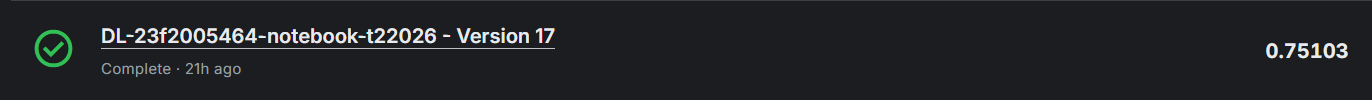

# Model from Scratch 

Choosed Model TextCNN

In [59]:
import pandas as pd
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)


duplicates = df.duplicated(subset=df.columns.drop("id")).sum()
print("Duplicates without id column ",duplicates)

df = df.drop_duplicates(subset=df.columns.drop("id")).reset_index(drop=True)


Duplicates without id column  183


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer().fit_transform(df["prompt"])

sim = cosine_similarity(tfidf)
import numpy as np
print(len(df))
np.fill_diagonal(sim, 0)
threshold = 0.90

pairs = np.argwhere(sim > threshold)

print("Highly similar pairs:", len(pairs))
for i, j in pairs[:20]:
    print("="*50)
    print(df.loc[i, "prompt"])
    print()
    print(df.loc[j, "prompt"])
    print("Similarity:", sim[i, j])

1817
Highly similar pairs: 6142
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

Which of the following is correct? What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Similarity: 0.9195299800883164
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

What is Martin Heidegger's view on the relationship between time and human existence?
Similarity: 0.904338715997894
What is accelerator-based light-ion fusion?

Determine the correct option: What is accelerator-based light-ion fusion?
Similarity: 0.9494485560888019
What is accelerator-based light-ion fusion?

Choose the correct answer: What is accelerator-based light-ion fusion? carefully.
Similarity: 0.926561581852595
What is accelerator-based light-ion fusion?

Choose the correct answer: What is

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import GroupShuffleSplit

from scipy.cluster.hierarchy import dendrogram

import matplotlib.pyplot as plt
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=1
)

X = vectorizer.fit_transform(df["prompt"])
similarity = cosine_similarity(X)
distance = 1 - similarity

clusterer = AgglomerativeClustering(
    metric="precomputed",
    linkage="average",
    n_clusters=None,
    distance_threshold=0.30
)

df["template_id"] = clusterer.fit_predict(distance)
cluster_sizes = df["template_id"].value_counts()
print("Number of clusters:", df["template_id"].nunique())

Number of clusters: 328


In [62]:

print(cluster_sizes.head(20))

template_id
103    16
202    16
199    15
165    14
228    14
33     14
88     13
44     13
152    13
180    13
46     13
232    13
56     13
159    12
82     12
137    12
154    12
42     12
285    12
268    12
Name: count, dtype: int64


In [63]:
for cluster in cluster_sizes.index[:1]:
    print(f"Cluster {cluster}")

    prompts = df[df["template_id"] == cluster]["prompt"]

    for p in prompts:
        print("-", p)

Cluster 103
- Pick the best possible answer: What is a trophic level in an ecological pyramid? from the following choices.
- Pick the best possible answer: What is a trophic level in an ecological pyramid? based on the given context.
- Select the most accurate option: What is a trophic level in an ecological pyramid? based on the given context.
- Determine the correct option: What is a trophic level in an ecological pyramid?
- Identify the correct statement: What is a trophic level in an ecological pyramid? carefully.
- Select the most accurate option: What is a trophic level in an ecological pyramid? carefully.
- Identify the correct statement: What is a trophic level in an ecological pyramid?
- Identify the correct statement: What is a trophic level in an ecological pyramid? among the listed options.
- What is a trophic level in an ecological pyramid?
- Select the most accurate option: What is a trophic level in an ecological pyramid? from the following choices.
- Which of the follow

In [64]:
from sklearn.model_selection import StratifiedGroupKFold

gss = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        df,
        y=df["answer"],              # optional
        groups=df["template_id"]
    )
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print(f"Train size      : {len(train_df)}")
print(f"Validation size : {len(val_df)}")

Train size      : 1434
Validation size : 383


In [65]:
train_df.head()

,id,prompt,A,B,C,D,E,answer,template_id
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,186
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,114
2,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,186
3,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,89
4,6,Identify the correct statement: What is the ef...,"An electric field, precisely aligned with the ...","A magnetic field, randomly aligned with the sp...","A magnetic field, precisely aligned with the s...","A gravitational field, randomly aligned with t...","A gravitational field, precisely aligned with ...",C,102


In [66]:
print("Train")
print(train_df["answer"].value_counts(normalize=True))

print("\nValidation")
print(val_df["answer"].value_counts(normalize=True))

Train
answer
B    0.244770
C    0.207113
A    0.195955
D    0.183403
E    0.168759
Name: proportion, dtype: float64

Validation
answer
C    0.328982
B    0.237598
D    0.172324
E    0.138381
A    0.122715
Name: proportion, dtype: float64


In [67]:
X_train = train_df.drop(columns=["answer", "template_id"])
X_val = val_df.drop(columns=["answer", "template_id"])
y_train = train_df["answer"]
y_val = val_df["answer"]


## Tokenization 

In [68]:
def tokenize(pairs):
    return [pair.split() for pair in pairs]


def combine_text(row):
    return [
        row["prompt"] + " <SEP> " + row["A"],
        row["prompt"] + " <SEP> " + row["B"],
        row["prompt"] + " <SEP> " + row["C"],
        row["prompt"] + " <SEP> " + row["D"],
        row["prompt"] + " <SEP> " + row["E"]
    ]

In [69]:
X_train["text"] = X_train.apply(combine_text, axis=1)
X_train["tokens"]=X_train["text"].apply(tokenize)
X_val["text"]=X_val.apply(combine_text,axis=1)
X_val["tokens"]=X_val["text"].apply(tokenize)
test_df["text"]=test_df.apply(combine_text,axis=1)
test_df["tokens"]=test_df["text"].apply(tokenize)
print(X_train["tokens"].iloc[0])

[['Pick', 'the', 'best', 'possible', 'answer:', 'What', 'is', 'Martin', "Heidegger's", 'view', 'on', 'the', 'relationship', 'between', 'time', 'and', 'human', 'existence?', 'among', 'the', 'listed', 'options.', '<SEP>', 'Martin', 'Heidegger', 'believes', 'that', 'humans', 'exist', 'within', 'a', 'time', 'continuum', 'that', 'is', 'infinite', 'and', 'does', 'not', 'have', 'a', 'defined', 'beginning', 'or', 'end.', 'The', 'relationship', 'to', 'the', 'past', 'involves', 'acknowledging', 'it', 'as', 'a', 'historical', 'era,', 'and', 'the', 'relationship', 'to', 'the', 'future', 'involves', 'creating', 'a', 'world', 'that', 'will', 'endure', 'beyond', "one's", 'own', 'time.'], ['Pick', 'the', 'best', 'possible', 'answer:', 'What', 'is', 'Martin', "Heidegger's", 'view', 'on', 'the', 'relationship', 'between', 'time', 'and', 'human', 'existence?', 'among', 'the', 'listed', 'options.', '<SEP>', 'Martin', 'Heidegger', 'believes', 'that', 'humans', 'do', 'not', 'exist', 'inside', 'time,', 'but'

## Vocab Creation 

In [70]:
from collections import Counter

counter = Counter()

for mcq_tokens in X_train["tokens"]:
    for option_tokens in mcq_tokens:
        counter.update(option_tokens)

In [71]:
counter.most_common(5)

[('the', 32693), ('of', 14857), ('is', 13523), ('a', 8939), ('<SEP>', 7170)]

In [72]:
vocab={
    "<PAD>":0,
    "<UNK>":1
}
for word in counter:
    vocab[word]=len(vocab)

print("Vocab Size :",len(vocab))

Vocab Size : 3487


In [73]:
def token_to_ids(vocab, tokens):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

In [74]:
X_train["input_ids"] = X_train["tokens"].apply(
    lambda row: [token_to_ids(vocab, option) for option in row]
)

X_val["input_ids"] = X_val["tokens"].apply(
    lambda row: [token_to_ids(vocab, option) for option in row]
)

test_df["input_ids"] = test_df["tokens"].apply(
    lambda row: [token_to_ids(vocab, option) for option in row]
)
print("Number of options:",
      len(X_train["tokens"].iloc[1]))

print("Number of encoded options:",
      len(X_train["input_ids"].iloc[1]))

print("First option tokens:")
print(X_train["tokens"].iloc[1][0])

print("\nFirst option IDs:")
print(X_train["input_ids"].iloc[1][0])

Number of options: 5
Number of encoded options: 5
First option tokens:
['What', 'is', 'accelerator-based', 'light-ion', 'fusion?', '<SEP>', 'Accelerator-based', 'light-ion', 'fusion', 'is', 'a', 'technique', 'that', 'uses', 'particle', 'accelerators', 'to', 'achieve', 'particle', 'kinetic', 'energies', 'sufficient', 'to', 'induce', 'light-ion', 'fusion', 'reactions.', 'This', 'method', 'is', 'relatively', 'easy', 'to', 'implement', 'and', 'can', 'be', 'done', 'in', 'an', 'efficient', 'manner,', 'requiring', 'only', 'a', 'vacuum', 'tube,', 'a', 'pair', 'of', 'electrodes,', 'and', 'a', 'high-voltage', 'transformer.', 'Fusion', 'can', 'be', 'observed', 'with', 'as', 'little', 'as', '10', 'kV', 'between', 'the', 'electrodes.']

First option IDs:
[7, 8, 106, 107, 108, 22, 109, 107, 110, 8, 29, 111, 25, 112, 113, 114, 40, 115, 113, 116, 117, 118, 40, 119, 107, 110, 120, 121, 122, 8, 123, 124, 40, 125, 16, 126, 127, 128, 74, 91, 129, 130, 131, 132, 29, 133, 134, 29, 135, 65, 136, 16, 29, 137,

In [75]:
X_train["length"] = X_train["input_ids"].map(len)
X_train["length"].describe()

count    1434.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
Name: length, dtype: float64

In [76]:
max_length = 256

def pad_truncate(ids):
    ids = ids[:max_length]

    if len(ids) < max_length:
        ids = ids + [vocab["<PAD>"]] * (max_length - len(ids))

    return ids

In [77]:
X_train["input_ids"] = X_train["input_ids"].apply(
    lambda mcq: [pad_truncate(option) for option in mcq]
)

X_val["input_ids"] = X_val["input_ids"].apply(
    lambda mcq: [pad_truncate(option) for option in mcq]
)

test_df["input_ids"] = test_df["input_ids"].apply(
    lambda mcq: [pad_truncate(option) for option in mcq]
)

In [78]:
print(len(X_train["input_ids"].iloc[0]))

5


In [79]:
X_train.shape


(1434, 11)

In [80]:
label2int = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4
}

y_train = y_train.map(label2int)
y_val=y_val.map(label2int)

In [81]:
import torch
from torch.utils.data import Dataset

class MCQDataset(Dataset):
    def __init__(self, input_ids, labels):
        self.input_ids = list(input_ids)
        self.labels = list(labels)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(
                self.input_ids[idx],
                dtype=torch.long
            ),
            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

In [82]:
train_dataset=MCQDataset( X_train["input_ids"],y_train)
validation_dataset=MCQDataset( X_val["input_ids"],y_val)
print( X_train["input_ids"])
print(y_train.dtype)

print(y_val.head())
print(y_val.dtype)

0       [[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 3, 13, 1...
1       [[7, 8, 106, 107, 108, 22, 109, 107, 110, 8, 2...
2       [[156, 3, 157, 158, 159, 7, 8, 9, 10, 11, 12, ...
3       [[161, 3, 162, 163, 7, 8, 3, 164, 65, 165, 74,...
4       [[161, 3, 162, 163, 7, 8, 3, 78, 193, 103, 29,...
                              ...                        
1429    [[7, 8, 3, 1354, 1355, 1356, 226, 1357, 1358, ...
1430    [[161, 3, 162, 163, 7, 8, 3, 2569, 37, 2570, 2...
1431    [[613, 3, 162, 159, 7, 32, 3383, 1259, 1240, 3...
1432    [[161, 3, 162, 163, 7, 8, 3, 789, 11, 65, 3, 7...
1433    [[2, 3, 4, 5, 6, 207, 65, 3, 208, 399, 400, 40...
Name: input_ids, Length: 1434, dtype: object
int64
0    2
1    4
2    3
3    2
4    1
Name: answer, dtype: int64
int64


In [83]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False
)
print(train_loader)
batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["labels"].shape)


torch.Size([32, 5, 256])
torch.Size([32])


In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np

In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TextCNNWithAttention(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=300,
        num_filters=100,
        kernel_sizes=(2, 3, 4),
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, kernel_size)
            for kernel_size in kernel_sizes
        ])

        self.attention_layers = nn.ModuleList([
            nn.Linear(num_filters, 1)
            for _ in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(
            num_filters * len(kernel_sizes),
            1
        )


    def forward(self, input_ids):

        batch_size, num_options, seq_length = input_ids.shape

        input_ids = input_ids.reshape(
            batch_size * num_options,
            seq_length
        )

        embedded = self.embedding(input_ids)

        embedded = embedded.permute(0, 2, 1)

        all_features = []

        for conv, attention in zip(
            self.convs,
            self.attention_layers
        ):

            conv_output = F.relu(conv(embedded))

            conv_output = conv_output.permute(0, 2, 1)

            attention_scores = attention(conv_output)

            attention_weights = torch.softmax(
                attention_scores,
                dim=1
            )

            attended_features = torch.sum(
                attention_weights * conv_output,
                dim=1
            )

            all_features.append(attended_features)

        combined_features = torch.cat(
            all_features,
            dim=1
        )

        combined_features = self.dropout(combined_features)

        option_scores = self.output_layer(combined_features)

        option_scores = option_scores.reshape(
            batch_size,
            num_options
        )

        return option_scores

In [86]:
model = TextCNNWithAttention(
    vocab_size=len(vocab),
    embedding_dim=300,
    num_filters=100,
    kernel_sizes=(2, 3, 4),
    dropout=0.3
).to(device)

In [87]:
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

In [88]:
criterion = torch.nn.CrossEntropyLoss()

In [89]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [90]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["labels"].shape)

torch.Size([32, 5, 256])
torch.Size([32])


In [91]:
    print("With Attention")
    epochs=5
    for epoch in range(epochs) :
    
        model.train()
        total_train_loss=0
        for step, batch in enumerate(train_loader, start=1):
      
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
    
            outputs = model(input_ids)
    
            loss = criterion(outputs, labels)
            total_train_loss+=loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        average_train_loss=total_train_loss/len(train_loader)
        
        #Validation 
        model.eval()
        all_logits = []
        all_labels = []

        total_val_loss =0
        correct=0
        total=0
        with torch.no_grad():
            for step, batch in enumerate(valid_loader,start=1):
                input_ids=batch["input_ids"].to(device)
                labels = batch["labels"].to(device)
    
                outputs = model(input_ids)
                    
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()
                predictions = torch.argmax(outputs, dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                all_logits.append(outputs.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                
            average_val_loss = total_val_loss / len(valid_loader)
            accuracy = (correct / total) * 100
        
        
        all_logits = np.concatenate(all_logits, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)
        
        map3 = map3_score(all_logits, all_labels)
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss      : {average_train_loss:.4f}")
        print(f"Validation Loss : {average_val_loss:.4f}")
        print(f"Validation Acc  : {accuracy:.2f}%")
        print(f"Validation MAP@3: {map3:.4f}")

With Attention
Epoch 1/5
Train Loss      : 1.3487
Validation Loss : 1.5507
Validation Acc  : 22.98%
Validation MAP@3: 0.4391
Epoch 2/5
Train Loss      : 0.6109
Validation Loss : 1.7550
Validation Acc  : 40.73%
Validation MAP@3: 0.5692
Epoch 3/5
Train Loss      : 0.3176
Validation Loss : 1.6986
Validation Acc  : 37.08%
Validation MAP@3: 0.5548
Epoch 4/5
Train Loss      : 0.1577
Validation Loss : 1.8183
Validation Acc  : 43.86%
Validation MAP@3: 0.5836
Epoch 5/5
Train Loss      : 0.0836
Validation Loss : 1.7688
Validation Acc  : 40.73%
Validation MAP@3: 0.5674


## ** Without attention***

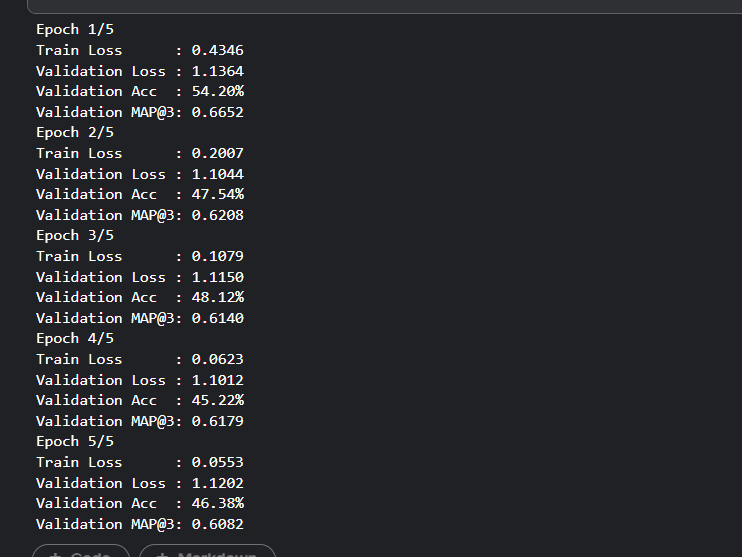

In [92]:
class TestDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(
                self.df.iloc[idx]["input_ids"],
                dtype=torch.long
            )
        }

In [93]:
test_dataset = TestDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [94]:


def create_submission(
    model,
    test_dataset,
    test_df,
    device,
    batch_size=32,
    filename="submission.csv"
):
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model.eval()

    all_predictions = []

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch["input_ids"].to(device)

            # [B, 5]
            outputs = model(input_ids)

            # [B, 3]
            top3 = torch.topk(
                outputs,
                k=3,
                dim=1
            ).indices

            all_predictions.extend(
                top3.cpu().numpy()
            )

    label_map = {
        0: "A",
        1: "B",
        2: "C",
        3: "D",
        4: "E"
    }

    predictions = [
        " ".join(label_map[i] for i in pred)
        for pred in all_predictions
    ]

    submission = pd.DataFrame({
        "id": test_df["id"],
        "prediction": predictions
    })

    submission.to_csv(
        filename,
        index=False
    )

    print(f"Submission saved as '{filename}'")

    return submission

In [95]:
submission = create_submission(
    model=model,
    test_dataset=test_dataset,
    test_df=test_df,
    device=device,
    batch_size=32,
    filename="submission.csv"
)

Submission saved as 'submission.csv'


# Analysis Report 